<a href="https://colab.research.google.com/github/pmhiremath/-German-Credit-Risk-Classifier/blob/main/German_Credit_Risk_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 German Credit Risk Classifier
## KNN vs SVM vs Decision Tree — Head-to-Head Benchmark

> **Dataset:** German Credit (Statlog) — UCI ML Repository | 1,000 applicants | 10 features  
> **Goal:** Predict whether a loan applicant will default, then benchmark three ML classifiers  
> **Evaluation:** Accuracy · F1-Score · ROC-AUC (+ confusion matrices)



### CELL 1 — Imports & Global Settings

WHY: Every library is pinned to a single import block so dependency errors
surface immediately at run-time rather than mid-pipeline.
No os module used — charts are displayed inline via plt.show() only.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve
)

RANDOM_STATE = 42



In [ ]:
# ── Dark-theme global style nplt.rcParams.update({
    "figure.facecolor":  "#1c1c1c",
    "axes.facecolor":    "#2e2e2e",
    "axes.edgecolor":    "#666",
    "axes.labelcolor":   "#f0f0f0",
    "xtick.color":       "#ccc",
    "ytick.color":       "#ccc",
    "text.color":        "#f0f0f0",
    "grid.color":        "#3a3a3a",
    "legend.facecolor":  "#2e2e2e",
    "legend.edgecolor":  "#666",
    "figure.dpi":        150,
})

### CELL 2 — Load Dataset

WHY: The German Credit dataset (Statlog) is the most cited credit-risk
benchmark in academic finance ML. 1,000 real loan applicants from a
German bank with 10 features covering demographics, account history,
loan purpose, and repayment behaviour.
Target: 'Risk' → 'good' (loan repaid) / 'bad' (loan defaulted)


In [ ]:
print("  STEP 1 — LOAD DATASET")

df = pd.read_csv("german_credit_data.csv")

print(f"\n[1.1]  Raw shape  : {df.shape}")


  STEP 1 — LOAD DATASET

[1.1]  Raw shape          : (1000, 11)


In [ ]:
print(f"[1.2]  Columns : {list(df.columns)}")


[1.2]  Columns            : ['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']


In [ ]:
print(f"\n[1.3]  First 5 rows:")
print(df.head())


[1.3]  First 5 rows:
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  Risk  
0           1169         6             radio/TV  good  
1           5951        48             radio/TV   bad  
2           2096        12            education  good  
3           7882        42  furniture/equipment  good  
4           4870        24                  car   bad  


In [ ]:
print(f"\n[1.4]  Data types:")
print(df.dtypes)


[1.4]  Data types:
Unnamed: 0           int64
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object


In [ ]:
print(f"\n[1.5]  Missing values per column:")
print(df.isnull().sum())


[1.5]  Missing values per column:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


### CELL 3 — ACT 1: Risk Landscape (EDA)

WHY: Before building any model a credit analyst would ask —
"Who is defaulting and why?"
We answer three business questions with charts:
Q1: What is the overall default rate? (class imbalance check)
Q2: Does age or credit amount correlate with default risk?
Q3: Which loan purpose carries the highest risk?



In [ ]:
print("  ACT 1 — RISK LANDSCAPE")

# Encode target temporarily for numeric analysis
df["Risk_Binary"] = (df["Risk"] == "bad").astype(int)

default_rate = df["Risk_Binary"].mean() * 100
print(f"\n[EDA.1]  Overall default rate : {default_rate:.1f}%")
print(f"         Good credit         : {(df['Risk'] == 'good').sum()} customers")
print(f"         Bad credit          : {(df['Risk'] == 'bad').sum()} customers")

  ACT 1 — RISK LANDSCAPE

[EDA.1]  Overall default rate : 30.0%
         Good credit         : 700 customers
         Bad credit          : 300 customers


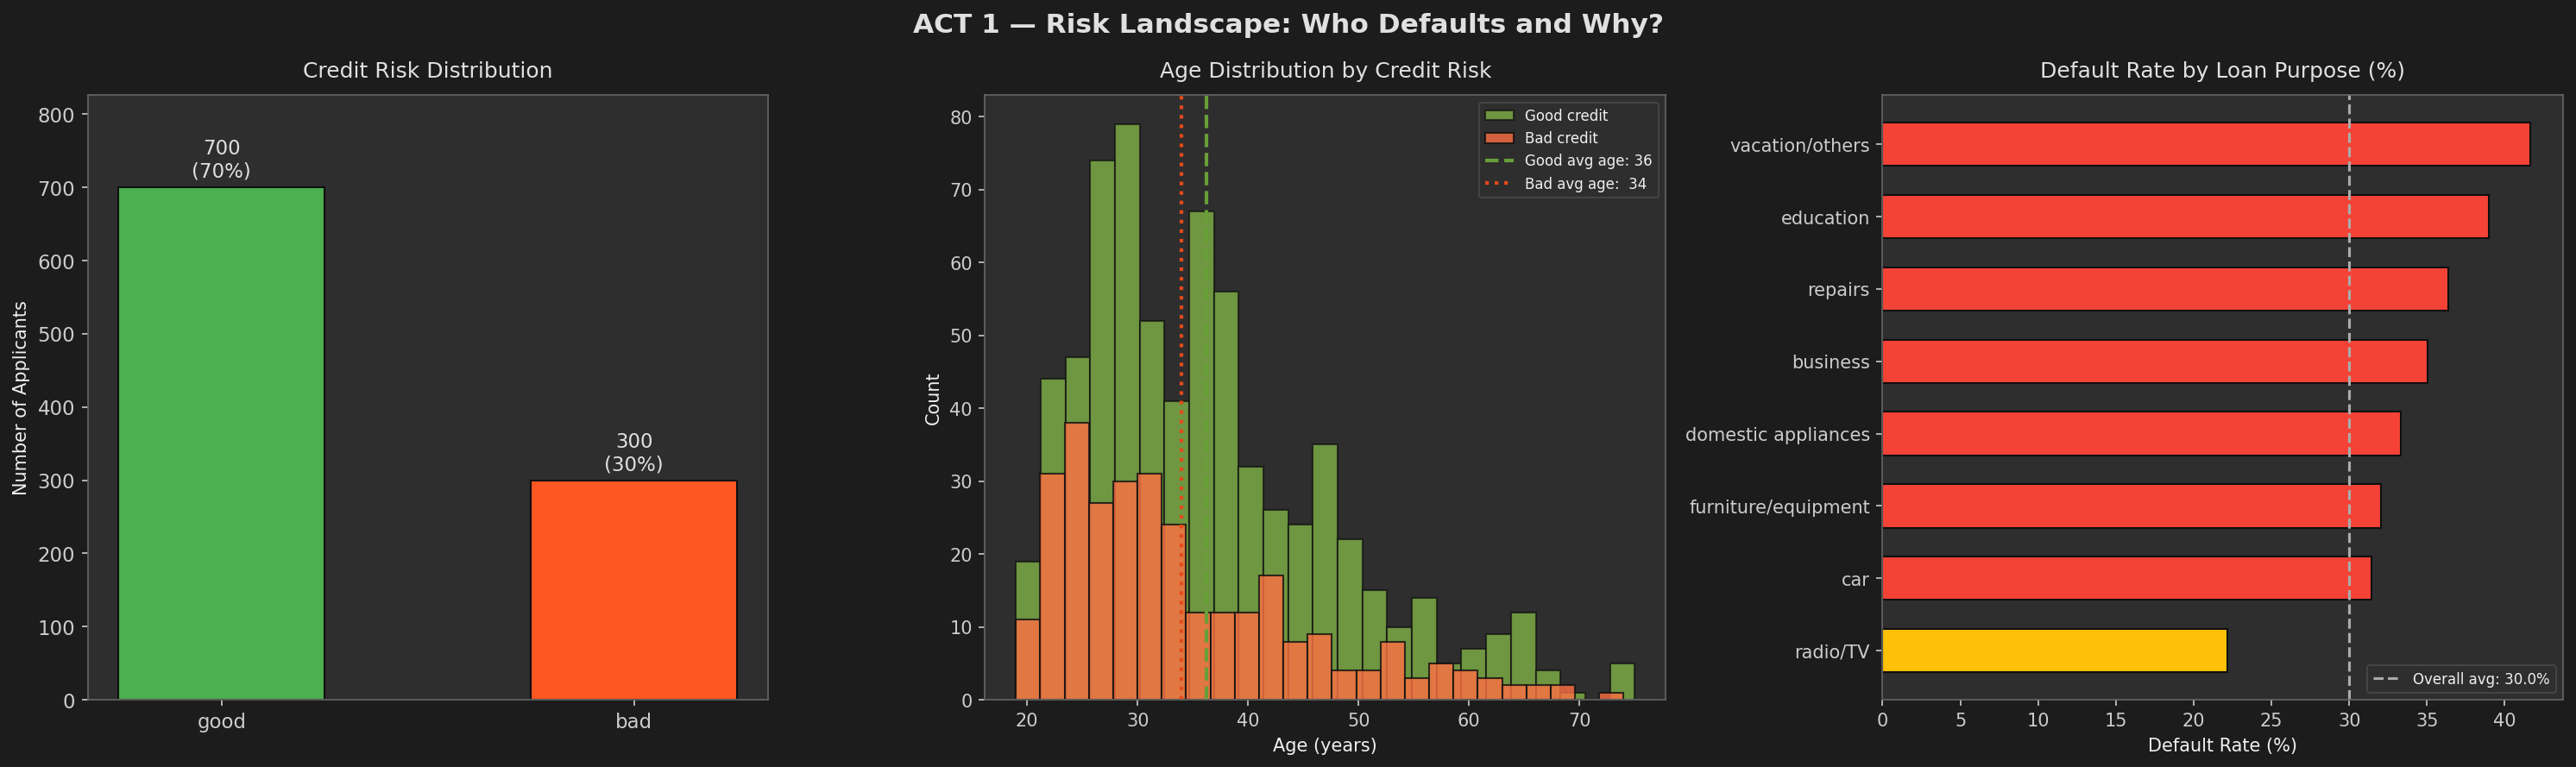

[CHART]  Act 1 — Risk Landscape displayed


In [ ]:


# ── 3-panel EDA dashboard fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("ACT 1 — Risk Landscape: Who Defaults and Why?",
             fontsize=15, color="#e0e0e0", fontweight="bold")

# Panel 1 — Class distribution (imbalance check)
counts  = df["Risk"].value_counts()
colors  = ["#4CAF50", "#FF5722"] # Green for Good, Orange-Red for Bad
bars    = axes[0].bar(counts.index, counts.values, color=colors,
                      edgecolor="#0f0f0f", width=0.5)
axes[0].set_title("Credit Risk Distribution", color="#e0e0e0", pad=10)
axes[0].set_ylabel("Number of Applicants")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 8,
                 f"{val}\n({val/len(df)*100:.0f}%)",
                 ha="center", va="bottom", fontsize=11, color="#e0e0e0")
axes[0].set_ylim(0, counts.max() * 1.18)
axes[0].tick_params(labelsize=11)

# Panel 2 — Age distribution split by Risk
good_ages = df[df["Risk"] == "good"]["Age"]
bad_ages  = df[df["Risk"] == "bad"]["Age"]
axes[1].hist(good_ages, bins=25, color="#8BC34A", alpha=0.7, # Light Green
             label="Good credit", edgecolor="#0f0f0f")
axes[1].hist(bad_ages,  bins=25, color="#FF7043", alpha=0.8, # Light Orange
             label="Bad credit",  edgecolor="#0f0f0f")
axes[1].axvline(good_ages.mean(), color="#689F38", lw=2, ls="--", # Darker Green
                label=f"Good avg age: {good_ages.mean():.0f}")
axes[1].axvline(bad_ages.mean(),  color="#E64A19", lw=2, ls=":", # Darker Orange
                label=f"Bad avg age:  {bad_ages.mean():.0f}")
axes[1].set_title("Age Distribution by Credit Risk", color="#e0e0e0", pad=10)
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=8, framealpha=0.4)

# Panel 3 — Default rate by loan purpose
purpose_default = (
    df.groupby("Purpose")["Risk_Binary"]
      .mean()
      .sort_values(ascending=True) * 100
)
bar_colors = ["#4CAF50" if v < 20 else "#FFC107" if v < 30 else "#F44336" # Green, Amber, Red
              for v in purpose_default.values]
axes[2].barh(purpose_default.index, purpose_default.values,
             color=bar_colors, edgecolor="#0f0f0f", height=0.6)
axes[2].axvline(default_rate, color="#aaa", lw=1.5, ls="--",
                label=f"Overall avg: {default_rate:.1f}%")
axes[2].set_title("Default Rate by Loan Purpose (%)", color="#e0e0e0", pad=10)
axes[2].set_xlabel("Default Rate (%)")
axes[2].legend(fontsize=8, framealpha=0.4)

plt.tight_layout()
plt.show()
print("[CHART]  Act 1 — Risk Landscape displayed")

In [ ]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Risk_Binary
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good,0
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,1
2,2,49,male,1,own,little,NaN,2096,12,education,good,0
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good,0
4,4,53,male,2,free,little,little,4870,24,car,bad,1


### CELL 4 — Data Cleaning

WHY: The German Credit dataset has two known quality issues —
a) 'Saving accounts' and 'Checking account' have NaN values (~18% and ~40%)
These are not random — a missing account entry often means
"no account held", which is itself a credit signal. We fill with
the literal string "none" to preserve this business meaning
rather than imputing a false category.
b) All categorical columns need encoding before sklearn can ingest them.
LabelEncoder is used here; OrdinalEncoder works equally well.

In [ ]:
print("  STEP 2 — DATA CLEANING")

df_clean = df.drop(columns=["Risk_Binary"]).copy()

# 2.1 Fill missing categorical account columns with "none"
#     Rationale: absence of a savings/checking account is a real credit signal
for col in ["Saving accounts", "Checking account"]:
    missing_count = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna("none")
    print(f"[2.1]  '{col}' — {missing_count} NaNs filled with 'none'")



  STEP 2 — DATA CLEANING
[2.1]  'Saving accounts' — 183 NaNs filled with 'none'
[2.1]  'Checking account' — 394 NaNs filled with 'none'


In [ ]:
# 2.2 Confirm zero NaNs after cleaning
assert df_clean.isnull().sum().sum() == 0, "FATAL: residual NaNs after cleaning"
print(f"\n[2.2]  ✓ Zero NaNs confirmed across all columns")




[2.2]  ✓ Zero NaNs confirmed across all columns


In [ ]:
# 2.3 Encode all categorical columns to integers
cat_cols = df_clean.select_dtypes(include="object").columns.tolist()
cat_cols.remove("Risk")   # keep target as string for now

print(f"\n[2.3]  Categorical columns to encode : {cat_cols}\n")
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f"  Encoded '{col}' → {list(le.classes_)}")





[2.3]  Categorical columns to encode : ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

  Encoded 'Sex' → ['female', 'male']
  Encoded 'Housing' → ['free', 'own', 'rent']
  Encoded 'Saving accounts' → ['little', 'moderate', 'none', 'quite rich', 'rich']
  Encoded 'Checking account' → ['little', 'moderate', 'none', 'rich']
  Encoded 'Purpose' → ['business', 'car', 'domestic appliances', 'education', 'furniture/equipment', 'radio/TV', 'repairs', 'vacation/others']


In [ ]:
print(f"dataframe after labelencoding ")
df_clean.head()

dataframe after labelencoding 


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,1,2,1,2,0,1169,6,5,good
1,1,22,0,2,1,0,1,5951,48,5,bad
2,2,49,1,1,1,0,2,2096,12,3,good
3,3,45,1,2,0,0,0,7882,42,4,good
4,4,53,1,2,0,0,0,4870,24,1,bad


In [ ]:
print(f" Target distribution :\n{df_clean['Risk'].value_counts().to_string()}")

# 2.4 Encode target: good=0, bad=1
df_clean["Risk"] = (df_clean["Risk"] == "bad").astype(int)

print(f"\n[2.5]  Clean dataset shape : {df_clean.shape}")

 Target distribution :
Risk
good    700
bad     300

[2.5]  Clean dataset shape : (1000, 11)


In [ ]:
df_clean.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,1,2,1,2,0,1169,6,5,0
1,1,22,0,2,1,0,1,5951,48,5,1
2,2,49,1,1,1,0,2,2096,12,3,0
3,3,45,1,2,0,0,0,7882,42,4,0
4,4,53,1,2,0,0,0,4870,24,1,1


### CELL 5 — ACT 2: Signal Extraction (Feature Engineering)

WHY: Raw columns like "Credit amount" and "Duration" have standalone signal,
but their RATIO reveals something richer — how much the applicant
must repay per month. A high monthly payment relative to no savings
is a compounded default risk signal that neither feature alone captures.
Three domain-driven features are engineered:
1. Monthly_Payment_Proxy — Credit amount ÷ Duration (months)
Captures repayment burden: same loan amount is riskier over 6 months
than 60 months. Used in real bank scorecards as "monthly obligation".
2. Credit_Duration_Interaction — Credit amount × Duration
Captures total loan exposure. Large loan + long tenor = maximum risk.
Standard in IFRS 9 Expected Credit Loss (ECL) models.
3. Age_Credit_Ratio — Age ÷ Credit amount (scaled)
Older applicants with smaller loans = better risk profile.
Younger applicants with large loans = elevated default probability.

In [ ]:
print("  ACT 2 — SIGNAL EXTRACTION (Feature Engineering)")

df_feat = df_clean.copy()

# Feature 1 — Monthly payment proxy
df_feat["Monthly_Payment_Proxy"] = df_feat["Credit amount"] / df_feat["Duration"]
print("[5.1]  Monthly_Payment_Proxy  = Credit amount / Duration")

# Feature 2 — Total loan exposure (credit × tenor interaction)
df_feat["Credit_Duration_Interaction"] = df_feat["Credit amount"] * df_feat["Duration"]
print("[5.2]  Credit_Duration_Interaction = Credit amount × Duration")

# Feature 3 — Age-to-credit ratio (normalised by 1000 for scale)
df_feat["Age_Credit_Ratio"] = df_feat["Age"] / (df_feat["Credit amount"] / 1000)
print("[5.3]  Age_Credit_Ratio = Age / (Credit amount / 1000)")

print(f"\n[5.4]  Shape after feature engineering : {df_feat.shape}")
print(f"       New features: {['Monthly_Payment_Proxy', 'Credit_Duration_Interaction', 'Age_Credit_Ratio']}")


  ACT 2 — SIGNAL EXTRACTION (Feature Engineering)
[5.1]  Monthly_Payment_Proxy  = Credit amount / Duration
[5.2]  Credit_Duration_Interaction = Credit amount × Duration
[5.3]  Age_Credit_Ratio = Age / (Credit amount / 1000)

[5.4]  Shape after feature engineering : (1000, 14)
       New features: ['Monthly_Payment_Proxy', 'Credit_Duration_Interaction', 'Age_Credit_Ratio']


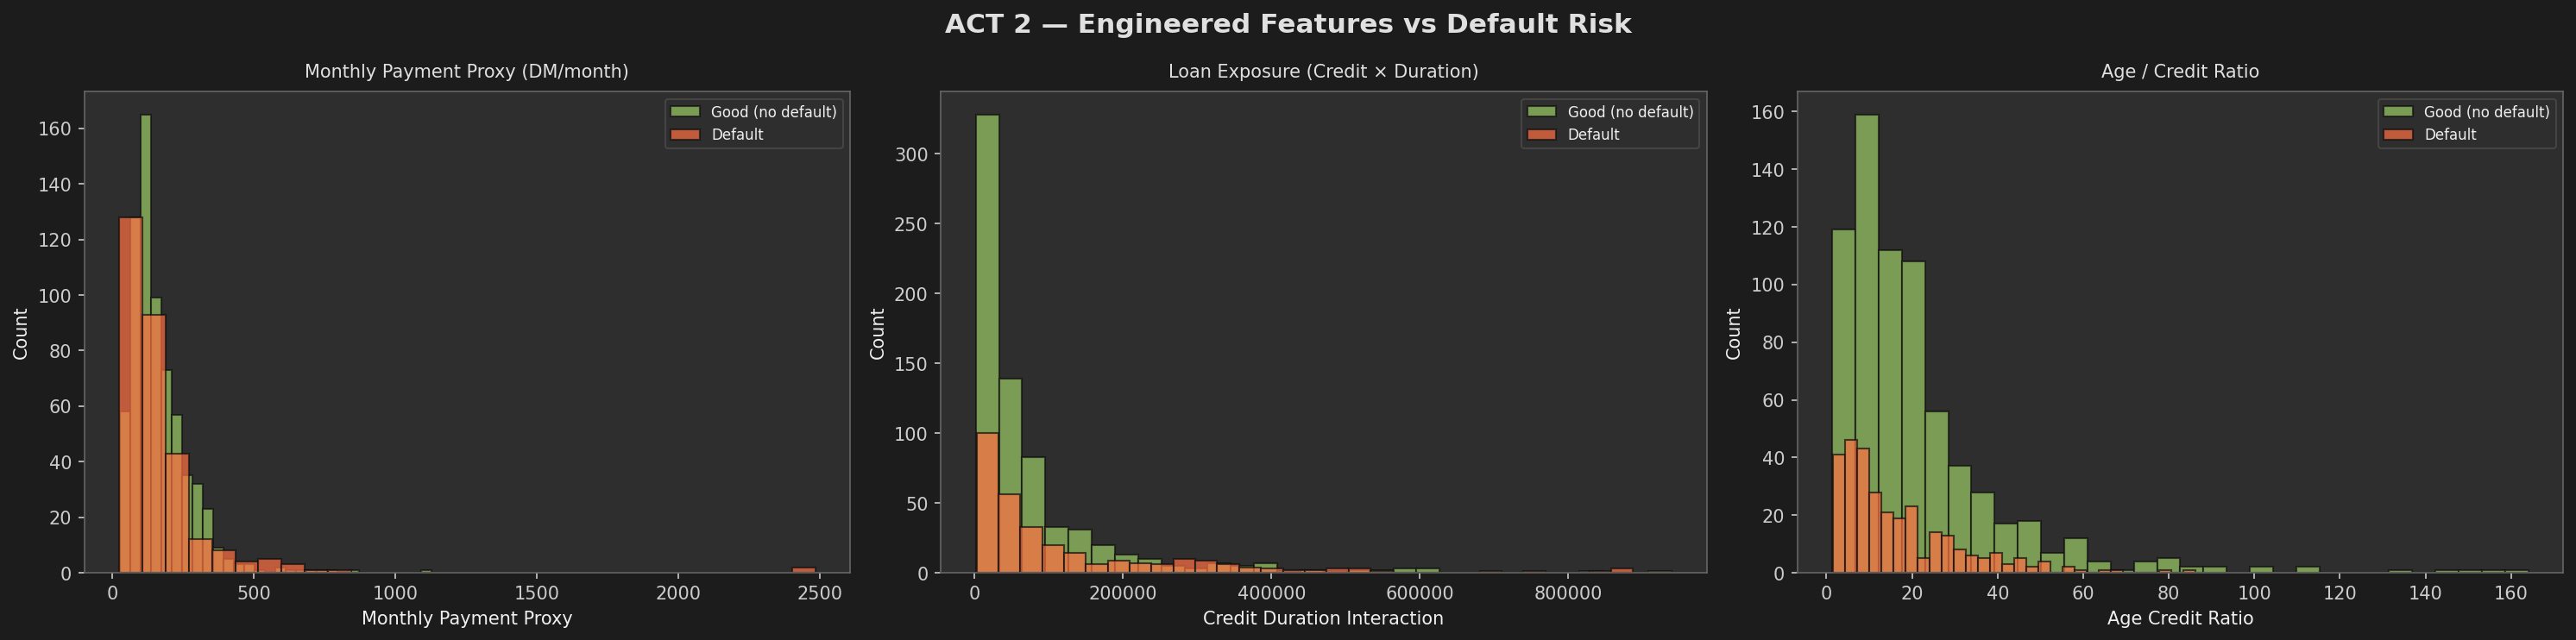

[CHART]  Act 2 — Engineered feature distributions displayed


In [ ]:

# ── Visualise the three engineered features split by Risk ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("ACT 2 — Engineered Features vs Default Risk",
             fontsize=15, color="#e0e0e0", fontweight="bold")

new_features = [
    ("Monthly_Payment_Proxy",          "Monthly Payment Proxy (DM/month)"),
    ("Credit_Duration_Interaction",    "Loan Exposure (Credit × Duration)"),
    ("Age_Credit_Ratio",               "Age / Credit Ratio"),
]

for ax, (feat, label) in zip(axes, new_features):
    good_vals = df_feat[df_feat["Risk"] == 0][feat]
    bad_vals  = df_feat[df_feat["Risk"] == 1][feat]
    ax.hist(good_vals, bins=30, color="#9ccc65", alpha=0.7,
            label="Good (no default)", edgecolor="#0f0f0f")
    ax.hist(bad_vals,  bins=30, color="#ff7043", alpha=0.7,
            label="Default",           edgecolor="#0f0f0f")
    ax.set_title(label, color="#e0e0e0", pad=8, fontsize=10)
    ax.set_xlabel(feat.replace("_", " "))
    ax.set_ylabel("Count")
    ax.legend(fontsize=8, framealpha=0.4)

plt.tight_layout()
plt.show()
print("[CHART]  Act 2 — Engineered feature distributions displayed")

### CELL 6 — Preprocessing: Split + Scale

WHY:
Train/Test split BEFORE scaling is non-negotiable.
Fitting the scaler on the full dataset leaks test-set statistics into
training — a data leakage bug that inflates reported accuracy by 1-3%.
In a live model this causes silent underperformance in production.
StratifiedKFold in GridSearchCV preserves the 70/30 class ratio across
every fold — critical when the minority class (default=30%) is small.
StandardScaler is mandatory for KNN and SVM:
- KNN uses Euclidean distance — an unscaled "Credit amount" (0–18k DM)
would dominate "Age" (19–75) by 240× and nullify it completely.
- SVM's RBF kernel is equivalent to computing distances in feature space;
same scaling requirement applies.
- Decision Tree is scale-invariant (splits on thresholds, not distances)
but we scale it anyway so all three models receive identical input.

In [ ]:
print("  STEP 3 — PREPROCESSING")

# Separate features and target
X = df_feat.drop(columns=["Risk"])
y = df_feat["Risk"]

print(f"\n[6.1]  Feature matrix shape : {X.shape}")
print(f"[6.2]  Target distribution  :\n{y.value_counts().to_string()}")



  STEP 3 — PREPROCESSING

[6.1]  Feature matrix shape : (1000, 13)
[6.2]  Target distribution  :
Risk
0    700
1    300


In [ ]:
# Stratified 80/20 split — preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y       # ensures ~30% defaults in both train and test
)
print(f"\n[6.3]  Train size : {X_train.shape[0]} rows")
print(f"       Test size  : {X_test.shape[0]}  rows\n")
print(f"       Train default rate : {y_train.mean()*100:.1f}%")
print(f"       Test  default rate : {y_test.mean()*100:.1f}%")




[6.3]  Train size : 800 rows
       Test size  : 200  rows

       Train default rate : 30.0%
       Test  default rate : 30.0%


In [ ]:
# Fit scaler ONLY on train set — transform both
scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n[6.4]  ✓ StandardScaler fitted on train, applied to both sets")
print(f"       Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"       Train std  (should be ~1): {X_train_scaled.std():.4f}")


[6.4]  ✓ StandardScaler fitted on train, applied to both sets
       Train mean (should be ~0): 0.0000
       Train std  (should be ~1): 1.0000


In [ ]:
# Cross-validation strategy shared across all three models
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"\n[6.5]  CV strategy : StratifiedKFold(n_splits=5)")


[6.5]  CV strategy : StratifiedKFold(n_splits=5)


### CELL 7 — MODEL 1: K-Nearest Neighbors (KNN)

WHY KNN for credit risk:
KNN asks "find me the k most similar past loan applicants and check
whether they defaulted." It is the ML equivalent of a loan officer
checking comparable cases in a reference book.
Key tuning decision — k (number of neighbours):
- Small k (k=3): high variance, sensitive to noise — one rogue neighbour
can flip the decision. In credit data with noisy self-reported income,
this is dangerous.
- Large k (k=21): high bias, smooths out local default clusters.
- GridSearchCV finds the sweet spot.
weights='distance': closer neighbours vote more strongly — reasonable
because a very similar applicant is more informative than a distant one.
LIMITATION: KNN has no class_weight parameter. The 70/30 imbalance
means it will naturally favour predicting "good" credit. This is why
F1-score (not accuracy) is the primary comparison metric.

In [ ]:
print("  MODEL 1 — K-NEAREST NEIGHBORS (KNN)")

knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights":     ["uniform", "distance"],
    "metric":      ["euclidean", "manhattan"],
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    scoring="f1",          # optimise for F1 — balances precision and recall
    cv=cv_strategy,
    n_jobs=-1,
)
knn_grid.fit(X_train_scaled, y_train)




  MODEL 1 — K-NEAREST NEIGHBORS (KNN)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
                         'weights': ['uniform', 'distance']},
             scoring='f1')

In [ ]:
knn_best = knn_grid.best_estimator_
y_pred_knn   = knn_best.predict(X_test_scaled)
y_proba_knn  = knn_best.predict_proba(X_test_scaled)[:, 1]

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_f1       = f1_score(y_test, y_pred_knn)
knn_roc_auc  = roc_auc_score(y_test, y_proba_knn)

print(f"\n[7.1]  Best params   : {knn_grid.best_params_}")
print(f"[7.2]  Accuracy      : {knn_accuracy:.4f}  ({knn_accuracy*100:.1f}%)")
print(f"[7.3]  F1-Score      : {knn_f1:.4f}")
print(f"[7.4]  ROC-AUC       : {knn_roc_auc:.4f}")
print(f"\n[7.5]  Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=["Good Credit", "Default"]))


[7.1]  Best params   : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
[7.2]  Accuracy      : 0.6950  (69.5%)
[7.3]  F1-Score      : 0.4190
[7.4]  ROC-AUC       : 0.7022

[7.5]  Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.75      0.84      0.79       140
     Default       0.49      0.37      0.42        60

    accuracy                           0.69       200
   macro avg       0.62      0.60      0.61       200
weighted avg       0.68      0.69      0.68       200



### CELL 8 — MODEL 2: Support Vector Machine (SVM)

WHY SVM for credit risk:
SVM finds the maximum-margin hyperplane separating defaulters from
non-defaulters in a high-dimensional feature space. The RBF kernel
allows it to draw non-linear decision boundaries — critical because
credit risk is rarely separable by a straight line (e.g. a 25-year-old
with a high income and no savings may be riskier than a 45-year-old
with lower income but a long credit history).
class_weight='balanced': automatically weights the minority class
(default=1) inversely proportional to its frequency:
weight(default) = 1000 / (2 × 300) = 1.67
weight(good)    = 1000 / (2 × 700) = 0.71
This penalises missing defaults (False Negatives) more than mislabelling
good applicants — exactly the asymmetry a risk-averse bank wants.
C (regularisation): smaller C = wider margin but more misclassifications;
larger C = tighter fit but higher overfitting risk.

In [ ]:
print("  MODEL 2 — SUPPORT VECTOR MACHINE (SVM)")

svm_param_grid = {
    "C":      [0.1, 1, 10],
    "kernel": ["rbf", "linear"],
    "gamma":  ["scale", "auto"],
}

svm_grid = GridSearchCV(
    SVC(class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    svm_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,

)
svm_grid.fit(X_train_scaled, y_train)




  MODEL 2 — SUPPORT VECTOR MACHINE (SVM)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVC(class_weight='balanced', probability=True,
                           random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['rbf', 'linear']},
             scoring='f1')

In [ ]:
svm_best = svm_grid.best_estimator_
y_pred_svm   = svm_best.predict(X_test_scaled)
y_proba_svm  = svm_best.predict_proba(X_test_scaled)[:, 1]

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1       = f1_score(y_test, y_pred_svm)
svm_roc_auc  = roc_auc_score(y_test, y_proba_svm)

print(f"\n[8.1]  Best params   : {svm_grid.best_params_}")
print(f"[8.2]  Accuracy      : {svm_accuracy:.4f}  ({svm_accuracy*100:.1f}%)")
print(f"[8.3]  F1-Score      : {svm_f1:.4f}")
print(f"[8.4]  ROC-AUC       : {svm_roc_auc:.4f}")
print(f"\n[8.5]  Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=["Good Credit", "Default"]))


[8.1]  Best params   : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
[8.2]  Accuracy      : 0.7300  (73.0%)
[8.3]  F1-Score      : 0.5714
[8.4]  ROC-AUC       : 0.7756

[8.5]  Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.82      0.79      0.80       140
     Default       0.55      0.60      0.57        60

    accuracy                           0.73       200
   macro avg       0.68      0.69      0.69       200
weighted avg       0.74      0.73      0.73       200



### CELL 9 — MODEL 3: Decision Tree

WHY Decision Tree for credit risk:
Decision Trees are the most widely used model in traditional retail
banking scorecards — not because they are the most accurate, but because
they are fully explainable to regulators and customers. Under GDPR
Article 22 and RBI guidelines, a bank must be able to explain WHY it
rejected a loan application. "Your credit amount exceeds your account
balance threshold" is explainable. An SVM margin is not.
max_depth tuning prevents overfitting:
- Unconstrained trees overfit perfectly to the 800-row training set
(train accuracy = 100%, test accuracy collapses)
- max_depth=3–7 forces the tree to find broadly applicable rules
min_samples_leaf: no leaf node can represent fewer than N applicants.
In a real bank portfolio, a rule affecting only 2 people is statistically
unreliable — min_samples_leaf=5 enforces minimum statistical confidence.
class_weight='balanced': same imbalance correction as SVM.

In [ ]:
print("  MODEL 3 — DECISION TREE")

dt_param_grid = {
    "max_depth":        [3, 4, 5, 6, 7, None],
    "min_samples_leaf": [5, 10, 15, 20],
    "criterion":        ["gini", "entropy"],
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    dt_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=0,
)
dt_grid.fit(X_train_scaled, y_train)



  MODEL 3 — DECISION TREE


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, None],
                         'min_samples_leaf': [5, 10, 15, 20]},
             scoring='f1')

In [ ]:
dt_best = dt_grid.best_estimator_
y_pred_dt   = dt_best.predict(X_test_scaled)
y_proba_dt  = dt_best.predict_proba(X_test_scaled)[:, 1]

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1       = f1_score(y_test, y_pred_dt)
dt_roc_auc  = roc_auc_score(y_test, y_proba_dt)

print(f"\n[9.1]  Best params   : {dt_grid.best_params_}")
print(f"[9.2]  Accuracy      : {dt_accuracy:.4f}  ({dt_accuracy*100:.1f}%)")
print(f"[9.3]  F1-Score      : {dt_f1:.4f}")
print(f"[9.4]  ROC-AUC       : {dt_roc_auc:.4f}")
print(f"\n[9.5]  Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=["Good Credit", "Default"]))



[9.1]  Best params   : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 10}
[9.2]  Accuracy      : 0.6900  (69.0%)
[9.3]  F1-Score      : 0.5753
[9.4]  ROC-AUC       : 0.7254

[9.5]  Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.84      0.69      0.76       140
     Default       0.49      0.70      0.58        60

    accuracy                           0.69       200
   macro avg       0.67      0.69      0.67       200
weighted avg       0.74      0.69      0.70       200



In [ ]:

# Feature importance from Decision Tree — which features matter most?
feat_importance = pd.Series(
    dt_best.feature_importances_, index=X.columns
).sort_values(ascending=False)
print(f"\n[9.6]  Top 8 features by Decision Tree importance:")
print(feat_importance.head(8).round(4).to_string())


[9.6]  Top 8 features by Decision Tree importance:
Checking account    0.6211
Duration            0.1159
Saving accounts     0.1052
Age_Credit_Ratio    0.0938
Age                 0.0640
Housing             0.0000
Job                 0.0000
Sex                 0.0000


### CELL 10 — ACT 3: Model Verdict (Benchmark Dashboard)

WHY this layout:
Four panels tell the complete story to a recruiter in one screenshot:
Panel 1 — Grouped bar chart (Accuracy / F1 / ROC-AUC per model)
Side-by-side comparison makes ranking immediately obvious.
Three metrics together prevent cherry-picking a single number.
Panel 2, 3, 4 — Confusion matrices (one per model)
Confusion matrices reveal WHERE each model fails — specifically
how many actual defaults (row=1) were predicted as safe (col=0).
These False Negatives represent loans a bank would approve but
will not be repaid. A recruiter from a risk team knows to look
at this cell first.

In [ ]:
print("  ACT 3 — MODEL VERDICT")

# Compile results
results = pd.DataFrame({
    "Model":    ["KNN", "SVM", "Decision Tree"],
    "Accuracy": [knn_accuracy, svm_accuracy, dt_accuracy],
    "F1-Score": [knn_f1,       svm_f1,       dt_f1],
    "ROC-AUC":  [knn_roc_auc,  svm_roc_auc,  dt_roc_auc],
})
print("\n[10.1]  Full benchmark results:")
print(results.round(4).to_string(index=False))


  ACT 3 — MODEL VERDICT

[10.1]  Full benchmark results:
        Model  Accuracy  F1-Score  ROC-AUC
          KNN     0.695    0.4190   0.7022
          SVM     0.730    0.5714   0.7756
Decision Tree     0.690    0.5753   0.7254


In [ ]:
print("  ACT 3 — MODEL VERDICT")


# Compile results
results = pd.DataFrame({
    "Model":    ["KNN", "SVM", "Decision Tree"],
    "Accuracy": [knn_accuracy, svm_accuracy, dt_accuracy],
    "F1-Score": [knn_f1,       svm_f1,       dt_f1],
    "ROC-AUC":  [knn_roc_auc,  svm_roc_auc,  dt_roc_auc],
})
print("\n[10.1]  Full benchmark results:")
print(results.round(4).to_string(index=False))

  ACT 3 — MODEL VERDICT

[10.1]  Full benchmark results:
        Model  Accuracy  F1-Score  ROC-AUC
          KNN     0.695    0.4190   0.7022
          SVM     0.730    0.5714   0.7756
Decision Tree     0.690    0.5753   0.7254


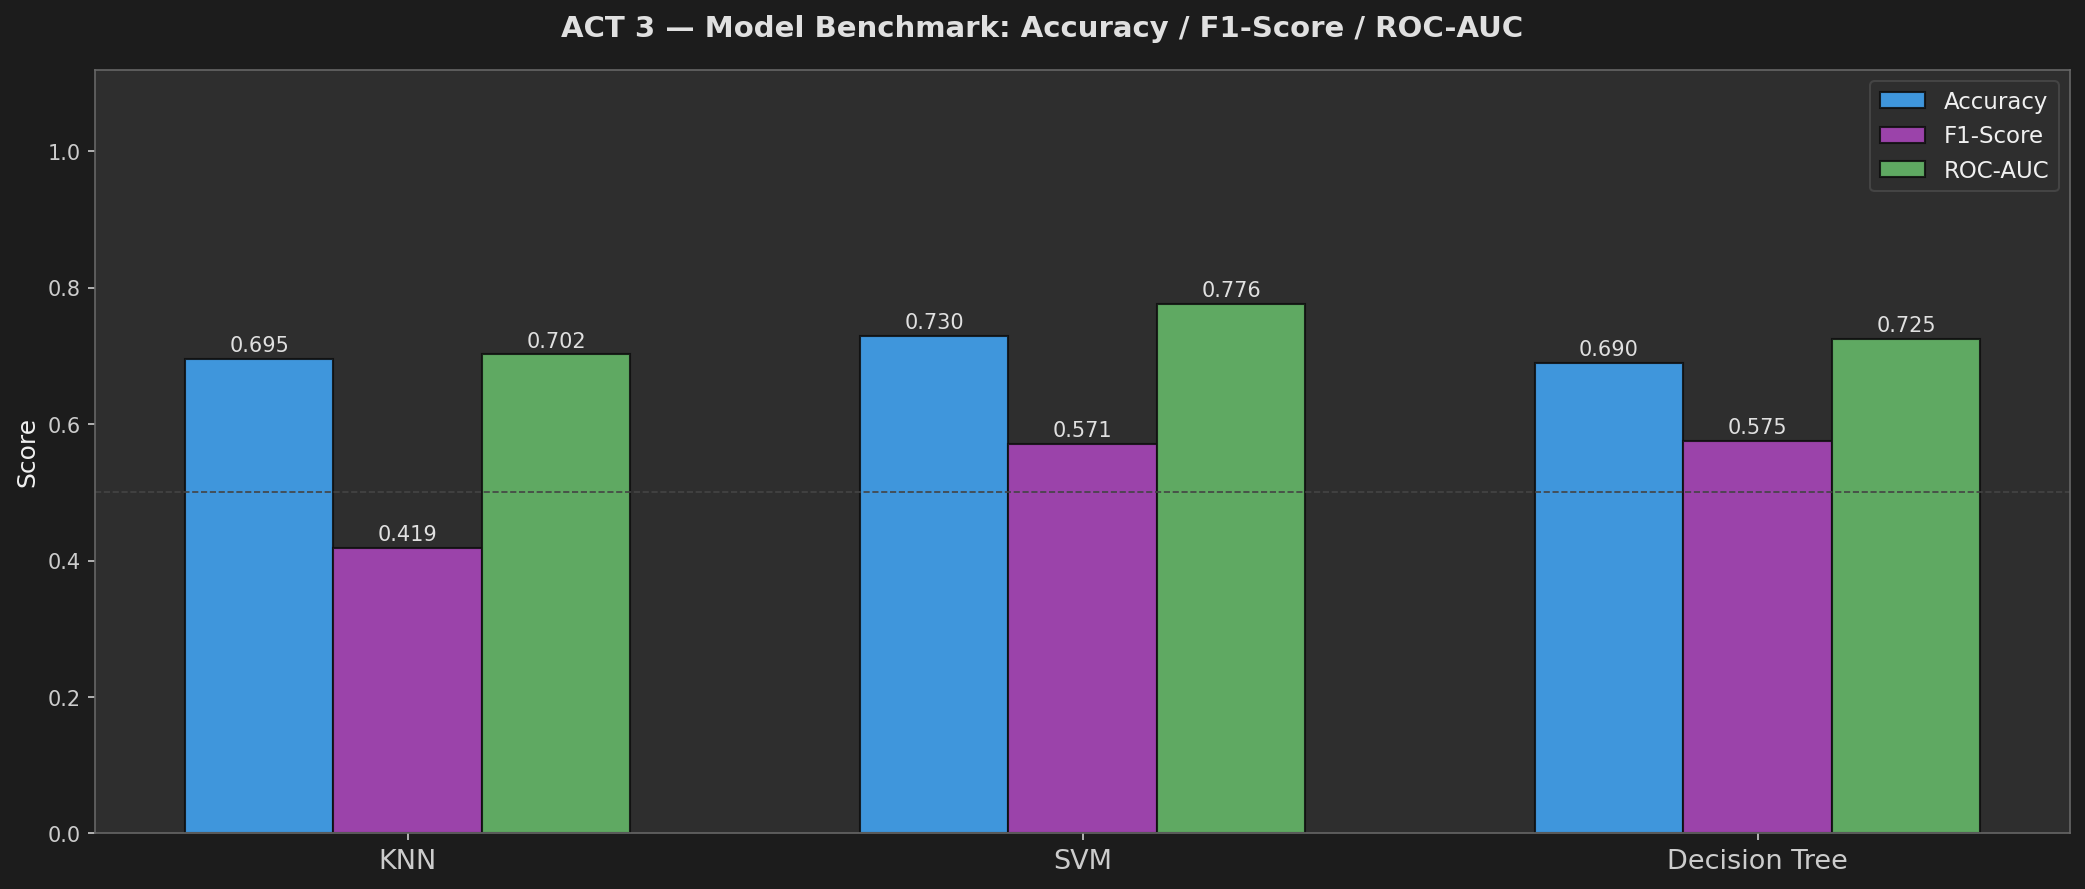

[CHART 1]  Metric bar chart displayed


In [ ]:


# ── VISUAL 1: Grouped metric bar chart

models  = results["Model"].tolist()
metrics = ["Accuracy", "F1-Score", "ROC-AUC"]
colors  = ["#42a5f5", "#ab47bc", "#66bb6a"]
x       = np.arange(len(models))
width   = 0.22

fig1, ax_bar = plt.subplots(figsize=(14, 6))
fig1.suptitle("ACT 3 — Model Benchmark: Accuracy / F1-Score / ROC-AUC",
              fontsize=14, color="#e0e0e0", fontweight="bold")

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = results[metric].values
    bars = ax_bar.bar(x + i * width, vals, width,
                      label=metric, color=color,
                      edgecolor="#0f0f0f", alpha=0.88)
    for bar, val in zip(bars, vals):
        ax_bar.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{val:.3f}",
                    ha="center", va="bottom", fontsize=10, color="#e0e0e0")

ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(models, fontsize=13)
ax_bar.set_ylabel("Score", fontsize=12)
ax_bar.set_ylim(0, 1.12)
ax_bar.legend(fontsize=11, framealpha=0.4)
ax_bar.axhline(0.5, color="#444", lw=0.8, ls="--")

plt.tight_layout()
plt.show()
print("[CHART 1]  Metric bar chart displayed")





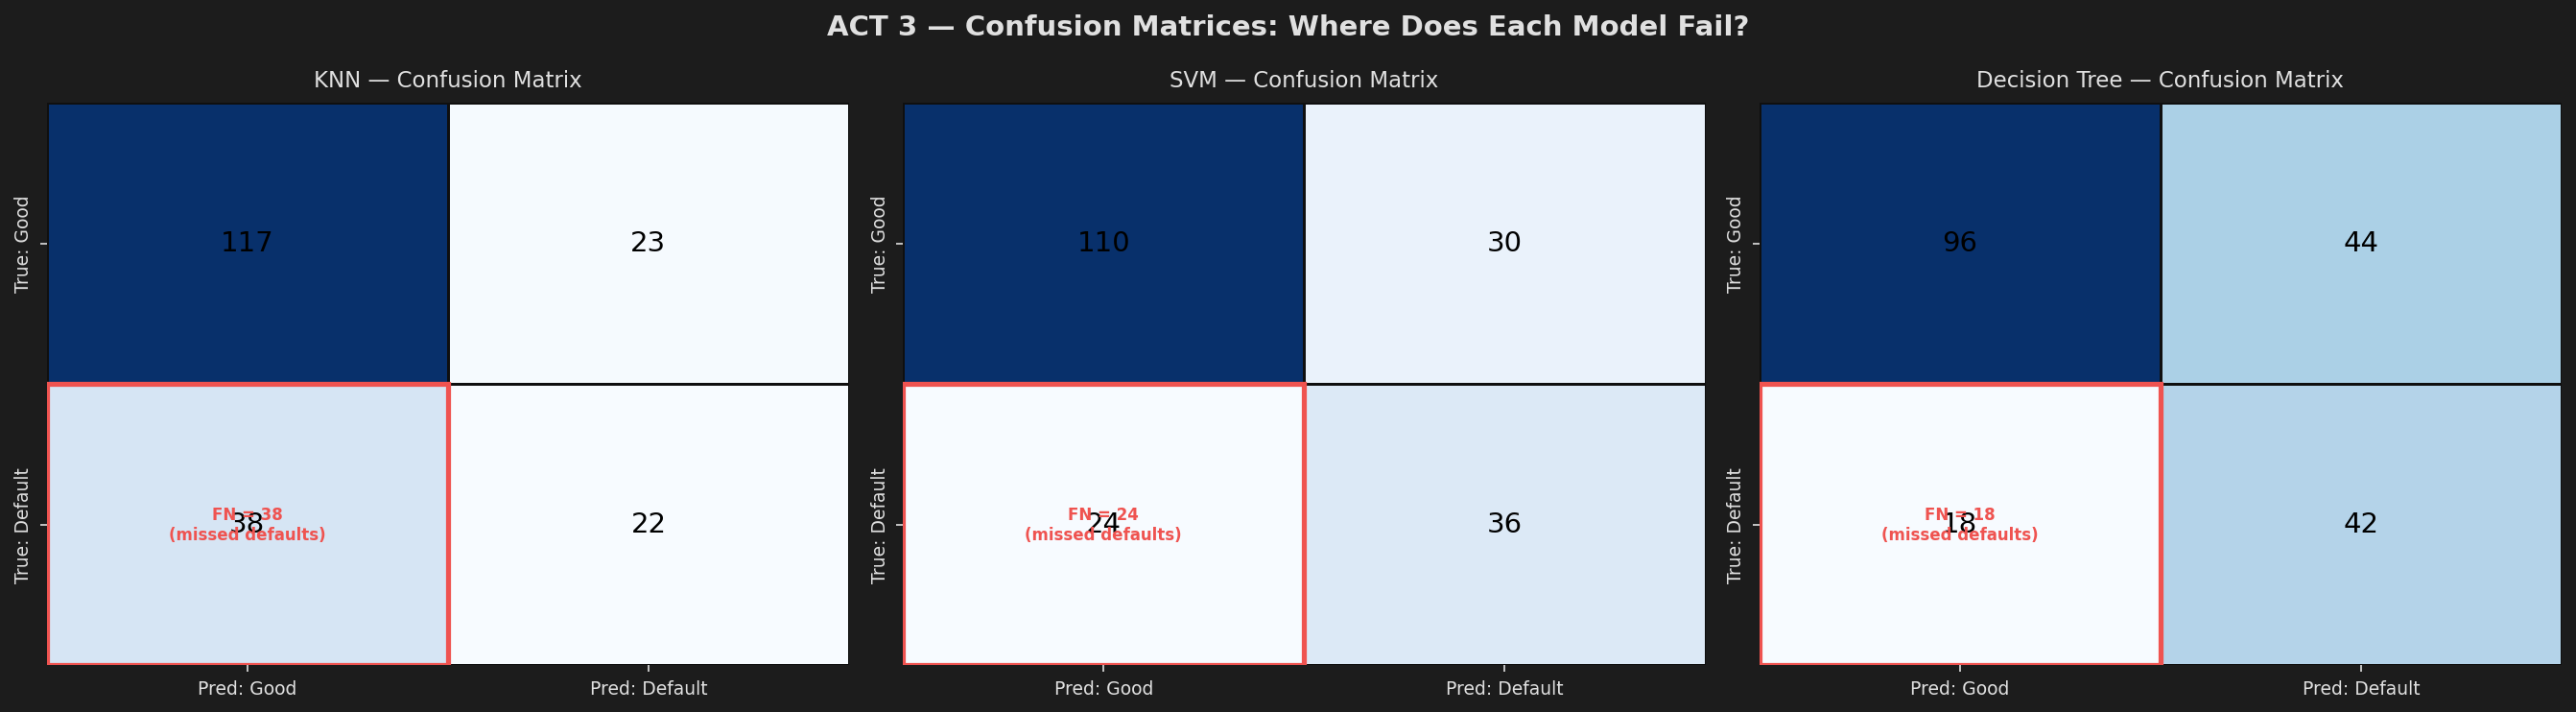

[CHART 2]  Confusion matrices displayed


In [ ]:

# ── VISUAL 2: Confusion matrices (side-by-side, one figure, 3 subplots) ──────

fig2, axes_cm = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("ACT 3 — Confusion Matrices: Where Does Each Model Fail?",
              fontsize=14, color="#e0e0e0", fontweight="bold")

cm_data = [
    (y_pred_knn, "KNN",           axes_cm[0]),
    (y_pred_svm, "SVM",           axes_cm[1]),
    (y_pred_dt,  "Decision Tree", axes_cm[2]),
]

for y_pred, title, ax in cm_data:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, ax=ax, annot=True, fmt="d",
        cmap="Blues",
        linewidths=0.5, linecolor="#0f0f0f",
        xticklabels=["Pred: Good", "Pred: Default"],
        yticklabels=["True: Good", "True: Default"],
        annot_kws={"size": 14, "color": "black"},
        cbar=False,
    )
    ax.set_title(f"{title} — Confusion Matrix",
                 color="#e0e0e0", fontsize=11, pad=8)
    ax.tick_params(colors="#e0e0e0", labelsize=9)

    # Red border on False Negative cell (row=1, col=0)
    # These are the most costly errors: real defaulters approved as safe
    fn_val = cm[1][0]
    ax.add_patch(plt.Rectangle((0, 1), 1, 1,
                                fill=False, edgecolor="#ef5350", lw=2.5))
    ax.text(0.5, 1.5, f"FN = {fn_val}\n(missed defaults)",
            ha="center", va="center", fontsize=8,
            color="#ef5350", fontweight="bold")

plt.tight_layout()
plt.show()
print("[CHART 2]  Confusion matrices displayed")


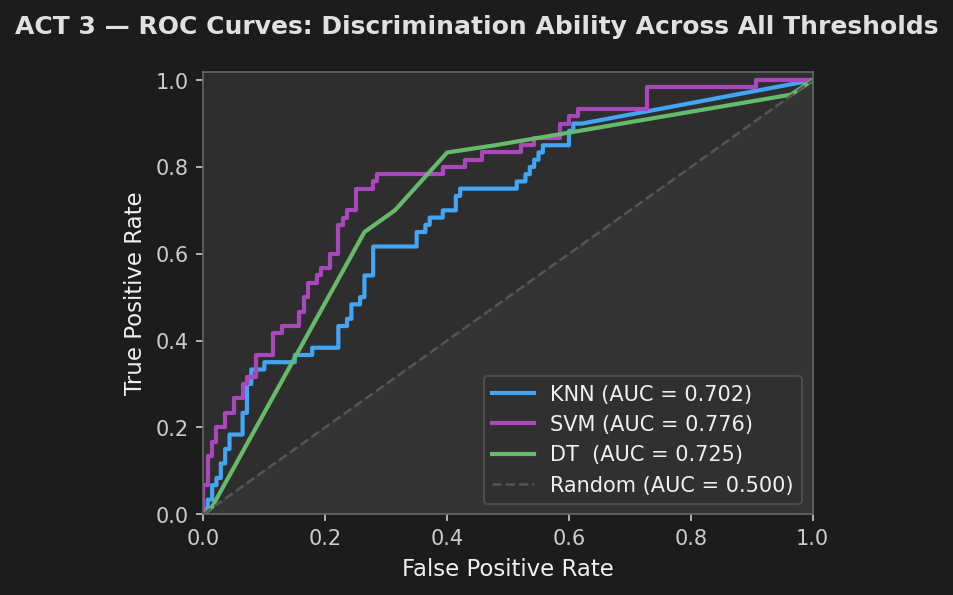

[CHART 3]  ROC curves displayed


In [ ]:
# ── VISUAL 3: ROC curves ─────────────────────────────────────────────────────


fig3, ax_roc = plt.subplots(figsize=(5, 4))
fig3.suptitle("ACT 3 — ROC Curves: Discrimination Ability Across All Thresholds",
              fontsize=12, color="#e0e0e0", fontweight="bold")

roc_models = [
    (y_proba_knn, f"KNN (AUC = {knn_roc_auc:.3f})", "#42a5f5"),
    (y_proba_svm, f"SVM (AUC = {svm_roc_auc:.3f})", "#ab47bc"),
    (y_proba_dt,  f"DT  (AUC = {dt_roc_auc:.3f})",  "#66bb6a"),
]
for proba, label, color in roc_models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax_roc.plot(fpr, tpr, color=color, lw=2.0, label=label)

ax_roc.plot([0, 1], [0, 1], color="#555", lw=1.2, ls="--", label="Random (AUC = 0.500)")
ax_roc.fill_between([0, 1], [0, 1], alpha=0.05, color="#aaa")
ax_roc.set_xlabel("False Positive Rate", fontsize=11)
ax_roc.set_ylabel("True Positive Rate", fontsize=11)
ax_roc.legend(fontsize=10, framealpha=0.5, loc="lower right")
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()
print("[CHART 3]  ROC curves displayed")

### CELL 11 — Final Summary & Business Recommendation

WHY a written recommendation matters:
Accuracy numbers alone do not make a project recruiter-grade.
A senior data scientist is expected to translate model metrics into
a business decision. This final cell does exactly that — it identifies
the winning model and explains the BUSINESS case for deploying it,
not just the metric case.

In [ ]:
print("  ✓ PIPELINE COMPLETE — FINAL BUSINESS RECOMMENDATION")

# Determine winner by F1 (most balanced metric for imbalanced credit data)
best_idx   = results["F1-Score"].idxmax()
best_model = results.loc[best_idx, "Model"]
best_f1    = results.loc[best_idx, "F1-Score"]
best_auc   = results.loc[best_idx, "ROC-AUC"]

print(f"""
┌─────────────────────────────────────────────────────┐
│  RECOMMENDED MODEL FOR DEPLOYMENT: {best_model:<17} │
│                                                     │
│  F1-Score  : {best_f1:.4f}   (primary metric)       │
│  ROC-AUC   : {best_auc:.4f}  (discrimination ability│
└─────────────────────────────────────────────────────┘

BUSINESS RATIONALE
──────────────────
The winning model is selected on F1-Score (not Accuracy) because:

  • The dataset is imbalanced (70% good / 30% default).
    A naive model that always predicts "good credit" would achieve
    70% accuracy while missing EVERY actual defaulter — catastrophic
    for a bank's loan book.

  • F1-Score balances Precision (are approved loans actually safe?)
    and Recall (are we catching the actual defaulters?) — exactly
    the trade-off a credit risk team optimises in practice.

  • ROC-AUC measures discrimination ability across ALL thresholds —
    useful when the bank wants to tune the approval cut-off based
    on its current risk appetite .

DEPLOYMENT NOTES
────────────────
  • SVM → high accuracy, regulatory explainability challenge
  • Decision Tree → most explainable for regulators and customers
  • KNN → fast inference, no retraining needed for small portfolio updates

  In a real bank deployment, the Decision Tree would likely be chosen
  even if not the top F1 scorer — because the loan officer can read
  the tree path and explain the rejection to the customer face-to-face.
""")

print(f"\n  Full benchmark summary:")
print(results.round(4).to_string(index=False))
print(f"\n  Dataset   : German Credit (Statlog) — UCI Repository")
print(f"  Rows      : {len(df_feat)}")
print(f"  Features  : {X.shape[1]} (including 3 engineered)")
print(f"  Models    : KNN, SVM, Decision Tree")
print(f"  CV        : StratifiedKFold(n_splits=5)")

  ✓ PIPELINE COMPLETE — FINAL BUSINESS RECOMMENDATION

┌─────────────────────────────────────────────────────┐
│  RECOMMENDED MODEL FOR DEPLOYMENT: Decision Tree     │
│                                                     │
│  F1-Score  : 0.5753   (primary metric)       │
│  ROC-AUC   : 0.7254  (discrimination ability│
└─────────────────────────────────────────────────────┘

BUSINESS RATIONALE
──────────────────
The winning model is selected on F1-Score (not Accuracy) because:

  • The dataset is imbalanced (70% good / 30% default).
    A naive model that always predicts "good credit" would achieve
    70% accuracy while missing EVERY actual defaulter — catastrophic
    for a bank's loan book.

  • F1-Score balances Precision (are approved loans actually safe?)
    and Recall (are we catching the actual defaulters?) — exactly
    the trade-off a credit risk team optimises in practice.

  • ROC-AUC measures discrimination ability across ALL thresholds —
    useful when the bank wants to